In [6]:
import pandas as pd
import numpy as np
df1=pd.DataFrame({'A':[1,2],'B':[3,4]})
df2=pd.DataFrame({'A':[5,6],'B':[7,8]})
pd.concat([df1,df2],axis=1)

,A,B,A,B
0,1,3,5,7
1,2,4,6,8


In [9]:
df1=pd.DataFrame({'A':[1,2],'B':[3,4]})
df2=pd.DataFrame({'A':[5,6],'C':[7,8]})
pd.concat([df1,df2])

,A,B,C
0,1,3.0,NaN
1,2,4.0,NaN
0,5,NaN,7.0
1,6,NaN,8.0


In [15]:
df1=pd.DataFrame({'A':[1,2],'B':[3,4]})
df2=pd.DataFrame({'A':[5,6],'C':[7,8]})
pd.concat([df1,df2],join='outer',ignore_index=True)


,A,B,C
0,1,3.0,NaN
1,2,4.0,NaN
2,5,NaN,7.0
3,6,NaN,8.0


In [16]:
df1=pd.DataFrame({'A':[1,2],'B':[3,4]})
df2=pd.DataFrame({'A':[5,6],'C':[7,8]})
pd.concat([df1,df2],join='inner',ignore_index=True)


,A
0,1
1,2
2,5
3,6


In [27]:
df1=pd.DataFrame({'A':[1,2],'B':[3,4]})
df2=pd.DataFrame({'A':[5,6],'C':[7,8]})
pd.concat([df1,df2],join='inner',ignore_index=False,keys=['Train','Test'],names=['Dataset'])


A
Dataset     
Train   0  1
        1  2
Test    0  5
        1  6

In [32]:
df1=pd.DataFrame({'A':[1,2],'B':[3,4]})
df2=pd.DataFrame({'A':[5,6],'C':[7,8]})
pd.concat([df1,df2],keys=['Train','Test'],names=['Dataset'],sort=True)


A    B    C
Dataset               
Train   0  1  3.0  NaN
        1  2  4.0  NaN
Test    0  5  NaN  7.0
        1  6  NaN  8.0

In [31]:
df1=pd.DataFrame({'A':[10,2],'B':[3,4]})
df2=pd.DataFrame({'A':[5,6],'C':[7,8]})
pd.concat([df1,df2],ignore_index=False,keys=['Train','Test'],names=['Dataset'],sort=False)


A    B    C
Dataset                
Train   0  10  3.0  NaN
        1   2  4.0  NaN
Test    0   5  NaN  7.0
        1   6  NaN  8.0

In [36]:
employees=pd.DataFrame({
    'emp_id':[1,2,3,4],
    'name':['A','B','C','D'],
    'dept_id':[10,20,10,30]
})
departments=pd.DataFrame({'dept_id':[10,20,40],'name':['HR','IT','Finance']})

pd.merge(employees,departments,on='dept_id')

,emp_id,name_x,dept_id,name_y
0,1,A,10,HR
1,3,C,10,HR
2,2,B,20,IT


In [37]:
pd.merge(employees,departments,on='dept_id',how='inner')

,emp_id,name_x,dept_id,name_y
0,1,A,10,HR
1,3,C,10,HR
2,2,B,20,IT


In [38]:
pd.merge(employees,departments,on='dept_id',how='outer')

,emp_id,name_x,dept_id,name_y
0,1.0,A,10,HR
1,3.0,C,10,HR
2,2.0,B,20,IT
3,4.0,D,30,NaN
4,NaN,NaN,40,Finance


In [39]:
pd.merge(employees,departments,on='dept_id',how='right')

,emp_id,name_x,dept_id,name_y
0,1.0,A,10,HR
1,3.0,C,10,HR
2,2.0,B,20,IT
3,NaN,NaN,40,Finance


In [40]:
pd.merge(employees,departments,on='dept_id',how='left')

,emp_id,name_x,dept_id,name_y
0,1,A,10,HR
1,2,B,20,IT
2,3,C,10,HR
3,4,D,30,NaN


In [43]:
pd.merge(employees,departments,left_on='dept_id',right_on='dept_id',how='outer',indicator=True)

,emp_id,name_x,dept_id,name_y,_merge
0,1.0,A,10,HR,both
1,3.0,C,10,HR,both
2,2.0,B,20,IT,both
3,4.0,D,30,NaN,left_only
4,NaN,NaN,40,Finance,right_only


In [44]:
pd.merge(employees,departments,left_on='dept_id',right_on='dept_id',how='outer',indicator=True,sort=True,copy=True)

,emp_id,name_x,dept_id,name_y,_merge
0,1.0,A,10,HR,both
1,3.0,C,10,HR,both
2,2.0,B,20,IT,both
3,4.0,D,30,NaN,left_only
4,NaN,NaN,40,Finance,right_only


In [47]:
pd.merge(employees,departments,left_on='dept_id',right_on='dept_id',how='outer',indicator=True,sort=True,copy=True,suffixes=['_emp','_dept'])

,emp_id,name_emp,dept_id,name_dept,_merge
0,1.0,A,10,HR,both
1,3.0,C,10,HR,both
2,2.0,B,20,IT,both
3,4.0,D,30,NaN,left_only
4,NaN,NaN,40,Finance,right_only


In [48]:
pd.merge(employees,departments,left_on='dept_id',right_on='dept_id',how='outer',indicator=True,sort=True,left_index=True)

,emp_id,name_x,dept_id,name_y,_merge
0.0,1.0,A,10,HR,both
0.0,3.0,C,10,HR,both
1.0,2.0,B,20,IT,both
NaN,4.0,D,30,NaN,left_only
2.0,NaN,NaN,40,Finance,right_only


In [49]:
pd.merge(employees,departments,left_on='dept_id',right_on='dept_id',how='outer',indicator=True,sort=True,right_index=True)

,dept_id,emp_id,name_x,dept_id_x,dept_id_y,name_y,_merge
NaN,0,NaN,NaN,NaN,10.0,HR,right_only
NaN,1,NaN,NaN,NaN,20.0,IT,right_only
NaN,2,NaN,NaN,NaN,40.0,Finance,right_only
0.0,10,1.0,A,10.0,NaN,NaN,left_only
2.0,10,3.0,C,10.0,NaN,NaN,left_only
1.0,20,2.0,B,20.0,NaN,NaN,left_only
3.0,30,4.0,D,30.0,NaN,NaN,left_only


In [53]:
employees=pd.DataFrame({
    'emp_id':[1,2,3,4],
    'name':['A','B','C','D'],
    'Active':['y','y','y','y']
})
print(employees.dtypes)
employees['emp_id']=employees['emp_id'].astype(int)
print(employees.dtypes)

emp_id     int64
name      object
Active    object
dtype: object
emp_id     int32
name      object
Active    object
dtype: object


In [55]:
employees['name']=employees['name'].replace('A','P')
print(employees['name'])

0    P
1    B
2    C
3    D
Name: name, dtype: object


# unit-2 Networkx

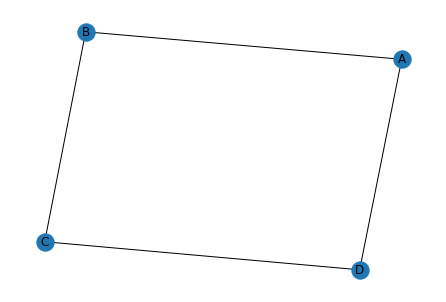

In [58]:
import networkx as nx
import matplotlib.pyplot as plt
g=nx.Graph()
g.add_node('A')
g.add_node('B')
g.add_node('C')
g.add_node('D')
g.add_edge('A','B')
g.add_edge('B','C')
g.add_edge('C','D')
g.add_edge('D','A')
nx.draw(g,with_labels=True)

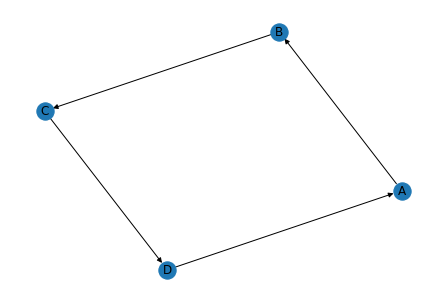

In [59]:
import networkx as nx
import matplotlib.pyplot as plt
g=nx.DiGraph()
g.add_node('A')
g.add_node('B')
g.add_node('C')
g.add_node('D')
g.add_edge('A','B')
g.add_edge('B','C')
g.add_edge('C','D')
g.add_edge('D','A')
nx.draw(g,with_labels=True)

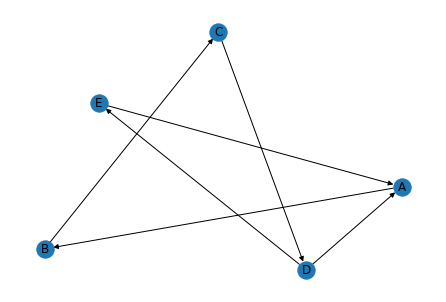

In [61]:
g.add_nodes_from(['A','B','C','D','E'])
g.add_edges_from([('A','B'),('B','C'),('C','D'),('D','E'),('E','A')])
nx.draw(g,with_labels=True)

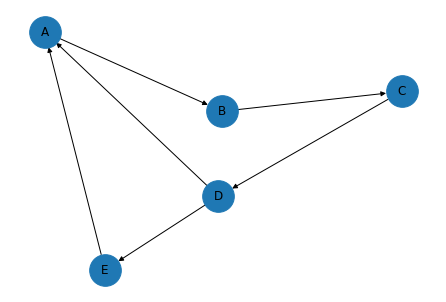

In [62]:
g.add_nodes_from(['A','B','C','D','E'])
g.add_edges_from([('A','B'),('B','C'),('C','D'),('D','A')])
nx.draw(g,with_labels=True,node_size=1000,node_color='green',edge_color='red',width=2)